# Ансамбли моделей

Сравним одиночное дерево, случайный лес и градиентный бустинг через стратифицированную кросс-валидацию. После сравнения исследуем важность признаков случайного леса.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")

## Модели и кросс-валидация

In [2]:
features, target = load_breast_cancer(return_X_y=True, as_frame=True)
validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=250, min_samples_leaf=2, n_jobs=1, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=150, learning_rate=0.08, random_state=42),
}

In [3]:
fold_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        features,
        target,
        cv=validation,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=1,
    )
    for fold, (f1, roc_auc) in enumerate(zip(scores["test_f1"], scores["test_roc_auc"]), start=1):
        fold_rows.append({"model": name, "fold": fold, "f1": f1, "roc_auc": roc_auc})

fold_results = pd.DataFrame(fold_rows)
summary = fold_results.groupby("model")[["f1", "roc_auc"]].agg(["mean", "std"])
summary

f1             roc_auc          
                       mean       std      mean       std
model                                                    
Decision Tree      0.936434  0.013080  0.943656  0.012492
Gradient Boosting  0.967080  0.021014  0.992179  0.006969
Random Forest      0.962599  0.014400  0.990369  0.008712

## Сравнение качества

/var/folders/pk/9xprbn3n0l976phskwjq30ww0000gn/T/ipykernel_35134/396002477.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_data, x="model", y="score", hue="metric", dodge=True, color="black", alpha=0.5, legend=False)


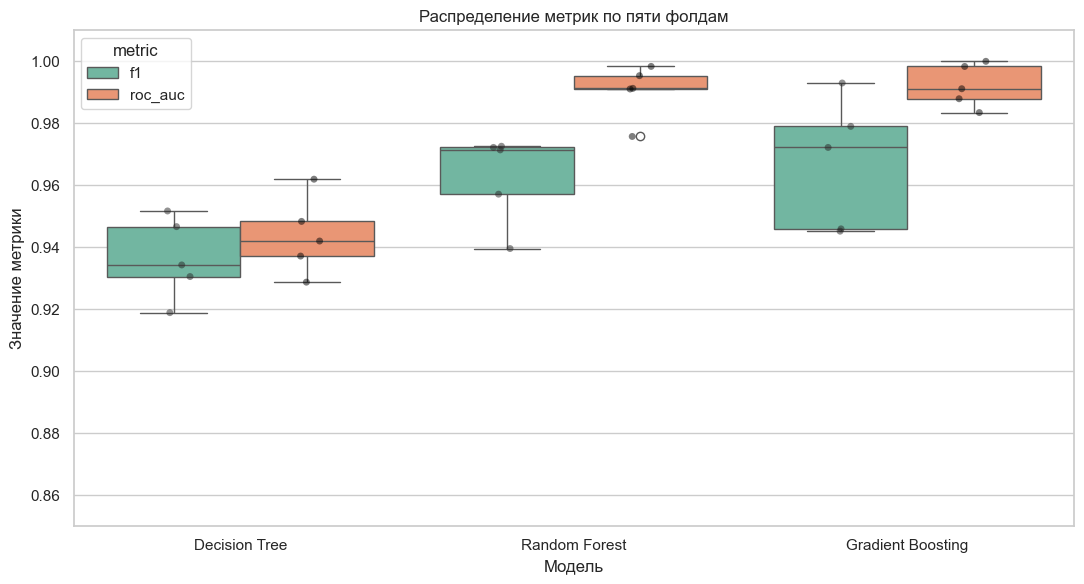

In [4]:
plot_data = fold_results.melt(
    id_vars=["model", "fold"],
    value_vars=["f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_data, x="model", y="score", hue="metric", palette="Set2")
sns.stripplot(data=plot_data, x="model", y="score", hue="metric", dodge=True, color="black", alpha=0.5, legend=False)
plt.title("Распределение метрик по пяти фолдам")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.ylim(0.85, 1.01)
plt.tight_layout()
plt.show()

## Важность признаков Random Forest

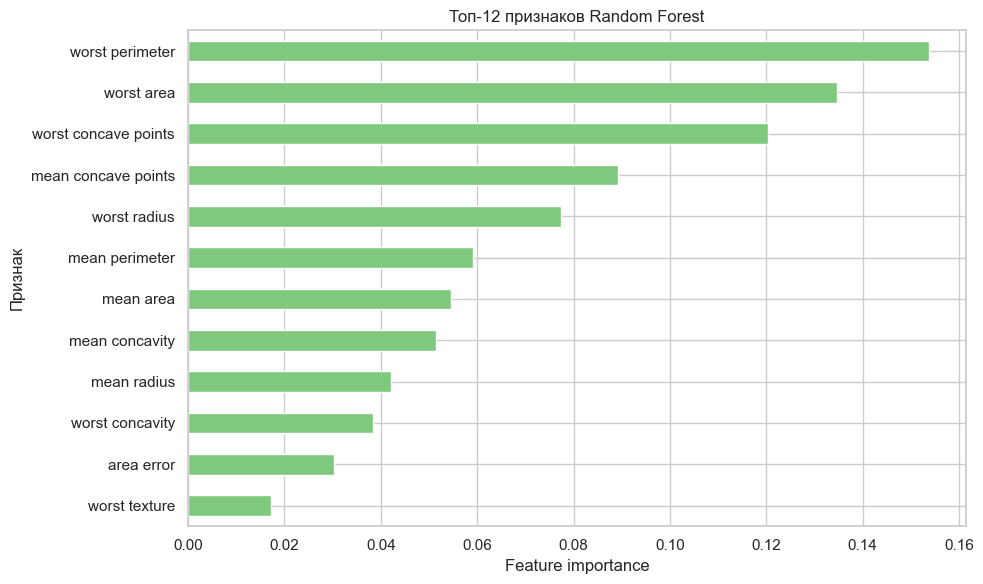

In [5]:
forest = models["Random Forest"]
forest.fit(features, target)
importance = pd.Series(forest.feature_importances_, index=features.columns).nlargest(12).sort_values()

importance.plot.barh(figsize=(10, 6), color="#7fc97f")
plt.title("Топ-12 признаков Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Вывод

Одиночное дерево проще объяснить, но ансамбли обычно дают более устойчивое качество. Разброс метрик между фолдами показывает стабильность оценки, а feature importance помогает понять, какие признаки чаще используются случайным лесом.

## Расширенный анализ bagging и случайного леса

In [6]:
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_predict, train_test_split

### Отдельное сравнение bagging-ансамблей

,model,accuracy,f1,roc_auc,roc_auc_std
3,Extra Trees,0.957833,0.966565,0.994253,0.004014
2,Random Forest,0.952569,0.962599,0.990138,0.007928
1,Bagging,0.950815,0.960986,0.988452,0.009618
0,Decision Tree,0.919190,0.936434,0.943656,0.011173


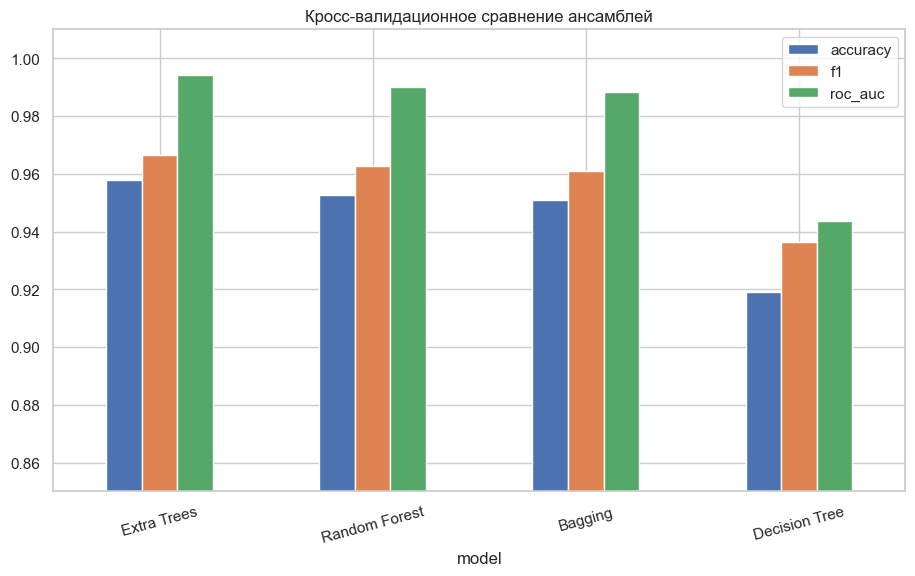

In [7]:
extended_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, min_samples_leaf=3),
        n_estimators=200,
        n_jobs=1,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=1, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=1, random_state=42),
}

extended_rows = []
for name, estimator in extended_models.items():
    scores = cross_validate(
        estimator,
        features,
        target,
        cv=validation,
        scoring={"f1": "f1", "roc_auc": "roc_auc", "accuracy": "accuracy"},
        n_jobs=1,
    )
    extended_rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
    })

extended_results = pd.DataFrame(extended_rows).sort_values("roc_auc", ascending=False)
display(extended_results)
extended_results.set_index("model")[["accuracy", "f1", "roc_auc"]].plot.bar(figsize=(11, 6))
plt.ylim(0.85, 1.01)
plt.title("Кросс-валидационное сравнение ансамблей")
plt.xticks(rotation=15)
plt.show()

### Глубина одиночного дерева

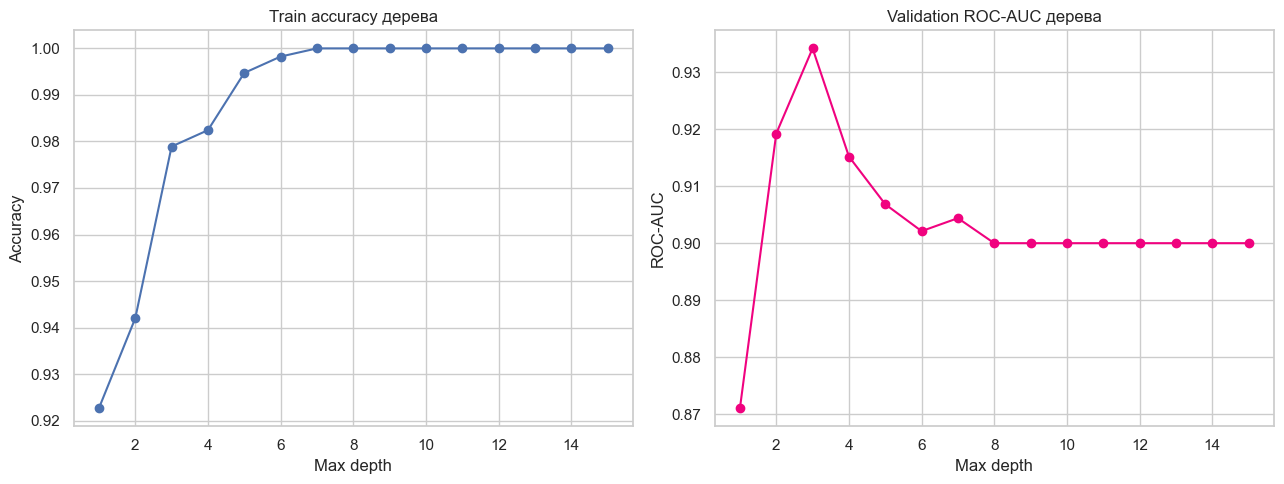

In [8]:
depth_rows = []
for depth in range(1, 16):
    estimator = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_score = estimator.fit(features, target).score(features, target)
    validation_score = cross_validate(estimator, features, target, cv=validation, scoring="roc_auc")["test_score"].mean()
    depth_rows.append({"depth": depth, "train_accuracy": train_score, "validation_roc_auc": validation_score})

depth_results = pd.DataFrame(depth_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(depth_results["depth"], depth_results["train_accuracy"], marker="o")
axes[0].set_title("Train accuracy дерева")
axes[0].set_xlabel("Max depth")
axes[0].set_ylabel("Accuracy")
axes[1].plot(depth_results["depth"], depth_results["validation_roc_auc"], marker="o", color="#f0027f")
axes[1].set_title("Validation ROC-AUC дерева")
axes[1].set_xlabel("Max depth")
axes[1].set_ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

### OOB-оценка Random Forest

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


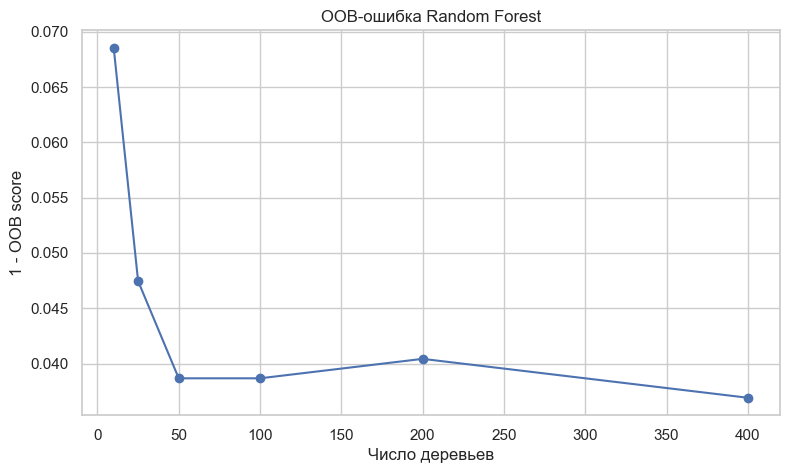

In [9]:
oob_rows = []
for trees in [10, 25, 50, 100, 200, 400]:
    estimator = RandomForestClassifier(
        n_estimators=trees,
        oob_score=True,
        bootstrap=True,
        n_jobs=1,
        random_state=42,
    ).fit(features, target)
    oob_rows.append({"trees": trees, "oob_error": 1 - estimator.oob_score_})

oob_results = pd.DataFrame(oob_rows)
plt.figure(figsize=(9, 5))
plt.plot(oob_results["trees"], oob_results["oob_error"], marker="o")
plt.title("OOB-ошибка Random Forest")
plt.xlabel("Число деревьев")
plt.ylabel("1 - OOB score")
plt.show()

### ROC-кривые на отложенной выборке

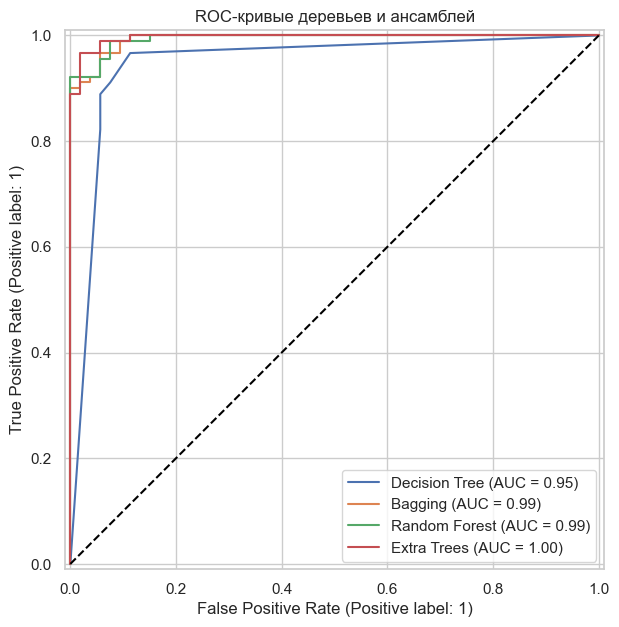

In [10]:
train_x, test_x, train_y, test_y = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)

fig, axis = plt.subplots(figsize=(9, 7))
fitted_extended = {}
for name, estimator in extended_models.items():
    estimator.fit(train_x, train_y)
    fitted_extended[name] = estimator
    RocCurveDisplay.from_predictions(test_y, estimator.predict_proba(test_x)[:, 1], name=name, ax=axis)
axis.plot([0, 1], [0, 1], linestyle="--", color="black")
axis.set_title("ROC-кривые деревьев и ансамблей")
plt.show()

### Сравнение важности признаков

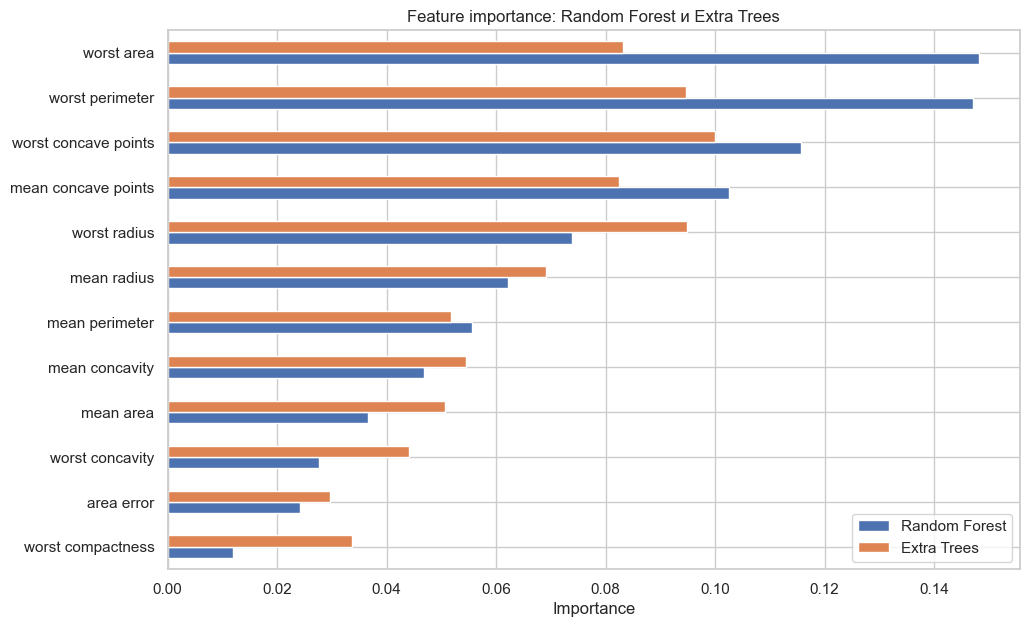

In [11]:
importance_comparison = pd.DataFrame({
    "Random Forest": fitted_extended["Random Forest"].feature_importances_,
    "Extra Trees": fitted_extended["Extra Trees"].feature_importances_,
}, index=features.columns)
top_features = importance_comparison.mean(axis=1).nlargest(12).index

importance_comparison.loc[top_features].sort_values("Random Forest").plot.barh(figsize=(11, 7))
plt.title("Feature importance: Random Forest и Extra Trees")
plt.xlabel("Importance")
plt.show()

### Ошибки лучшей модели

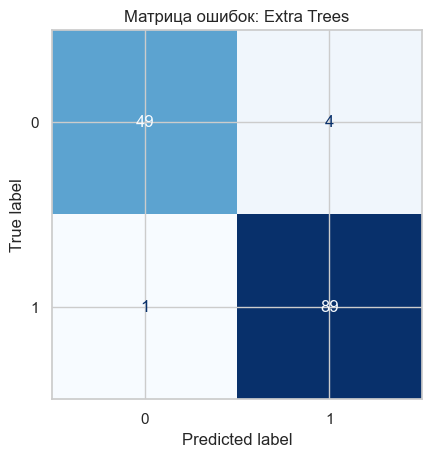

In [12]:
best_name = extended_results.iloc[0]["model"]
best_estimator = fitted_extended[best_name]
best_prediction = best_estimator.predict(test_x)

ConfusionMatrixDisplay.from_predictions(test_y, best_prediction, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок: {best_name}")
plt.show()

### Итог расширенного анализа

Bagging снижает дисперсию отдельных деревьев за счёт bootstrap-выборок. Random Forest дополнительно выбирает случайные подмножества признаков, а Extra Trees усиливает рандомизацию порогов. OOB-ошибка даёт внутреннюю оценку качества без отдельной validation-выборки.